# Project Metrics

Run after completing both Signal and Image notebooks.

**Cell 1** — Training curve for a single run. Set  or  and  to match the notebook parameter cell.

**Cell 2** — Comparison plot (macro AUROC per epoch) across all three models.
- Signal metrics:  (iter_signal)
- Image metrics:   (iter_kd, iter_nokd)

> If a model was re-trained with different epochs, delete the relevant  file (or run ) so metrics are re-saved on the next run.

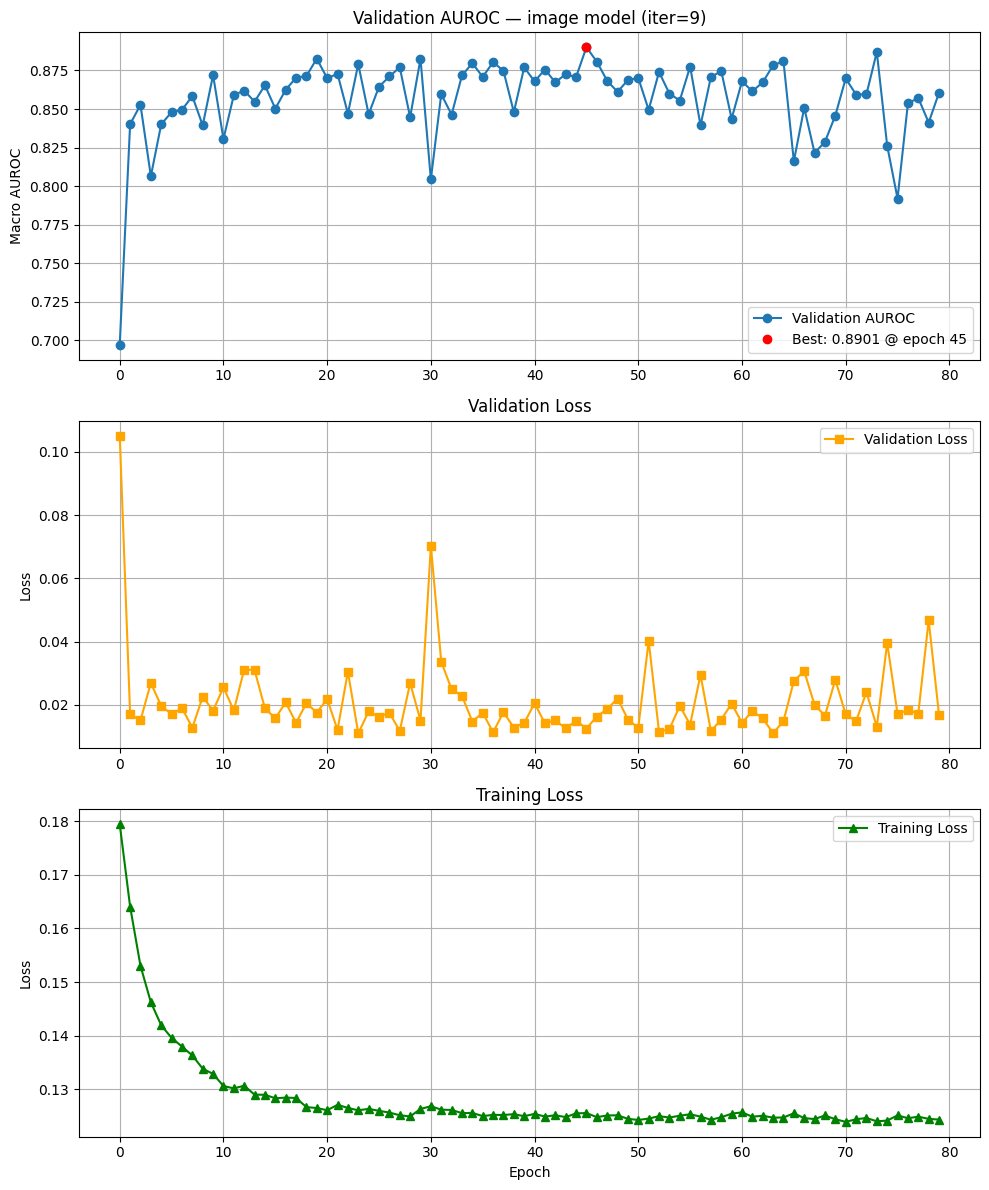

Epochs recorded: 80
Best AUROC: 0.890073 at epoch 45


In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

# ── Configure ─────────────────────────────────────────────────────────────
# model: "signal" reads record_history/metrics_signal.h5
#        "image"  reads record_history/metrics.h5
model  = "image"
iter   = 9   # iter used in the notebook parameter cell

file_path = "record_history/metrics_signal.h5" if model == "signal" else "record_history/metrics.h5"

# ── Plot ───────────────────────────────────────────────────────────────────
try:
    with h5py.File(file_path, "r") as mh5:
        score_key      = f"valid_score_{iter}"
        loss_key       = f"valid_loss_{iter}"
        train_loss_key = f"train_loss_{iter}"

        for key in [score_key, loss_key, train_loss_key]:
            if key not in mh5:
                raise KeyError(f"Dataset {key!r} not found. Available: {list(mh5.keys())}")

        score_list      = mh5[score_key][()]
        valid_loss_list = mh5[loss_key][()]
        train_loss_list = mh5[train_loss_key][()]

    best_i = int(np.argmax(score_list))

    fig, axes = plt.subplots(3, 1, figsize=(10, 12))

    axes[0].plot(score_list, marker="o", linestyle="-", label="Validation AUROC")
    axes[0].plot(best_i, score_list[best_i], "ro",
                 label=f"Best: {score_list[best_i]:.4f} @ epoch {best_i}")
    axes[0].set_title(f"Validation AUROC — {model} model (iter={iter})")
    axes[0].set_ylabel("Macro AUROC")
    axes[0].grid(True)
    axes[0].legend()

    axes[1].plot(valid_loss_list, marker="s", color="orange", label="Validation Loss")
    axes[1].set_title("Validation Loss")
    axes[1].set_ylabel("Loss")
    axes[1].grid(True)
    axes[1].legend()

    axes[2].plot(train_loss_list, marker="^", color="green", label="Training Loss")
    axes[2].set_title("Training Loss")
    axes[2].set_xlabel("Epoch")
    axes[2].set_ylabel("Loss")
    axes[2].grid(True)
    axes[2].legend()

    plt.tight_layout()
    plt.show()

    print(f"Epochs recorded: {len(score_list)}")
    print(f"Best AUROC: {score_list[best_i]:.6f} at epoch {best_i}")

except FileNotFoundError:
    print(f"File not found: {file_path}")
except KeyError as e:
    print(f"Error: {e}")


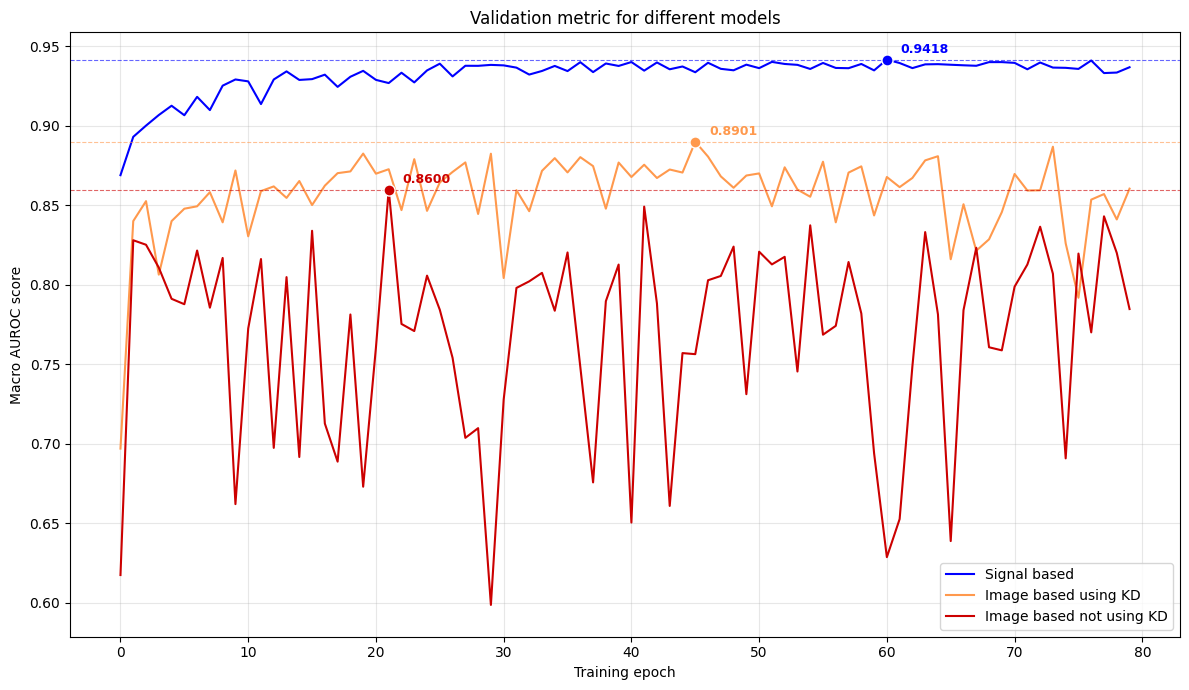

Best scores:
  Signal based: 0.941758 at epoch 60
  Image based using KD: 0.890073 at epoch 45
  Image based not using KD: 0.859986 at epoch 21


In [2]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import os

# ── Configure which training runs to compare ──────────────────────────────
# These should match the 'iter' value set in each notebook's parameter cell.
iter_signal = 10   # iter used in Signal notebook (Cell 32)
iter_kd   = 9   # iter used in Image notebook (using_kd=True)    # iter used in Image notebook with using_kd=True  (Cell 22)
iter_nokd = 8   # iter used in Image notebook (using_kd=False)    # iter used in Image notebook with using_kd=False (Cell 22)
# Note: if KD and no-KD were run as separate iter values, set them individually.

signal_h5  = 'record_history/metrics_signal.h5'
image_h5   = 'record_history/metrics.h5'

# ── Load data ──────────────────────────────────────────────────────────────
def load_scores(h5_path, iter_val):
    """Return valid_score array for the given iter, or None if not found."""
    if not os.path.exists(h5_path):
        print(f'Missing: {h5_path}')
        return None
    with h5py.File(h5_path, 'r') as f:
        key = f'valid_score_{iter_val}'
        if key not in f:
            print(f'Key {key!r} not found in {h5_path}. Available: {list(f.keys())}')
            return None
        return f[key][()]

score_signal = load_scores(signal_h5, iter_signal)
score_kd     = load_scores(image_h5,  iter_kd)

# no-KD may be a different iter or the same file
if iter_nokd != iter_kd:
    score_nokd = load_scores(image_h5, iter_nokd)
else:
    # Same iter — can only be one run; skip no-KD unless a different iter was used
    score_nokd = None
    print(f'iter_nokd == iter_kd ({iter_nokd}); set iter_nokd to a different value if you ran a no-KD training.')

# ── Plot ───────────────────────────────────────────────────────────────────
plt.figure(figsize=(12, 7))

lines, best_info = [], []

if score_signal is not None:
    line, = plt.plot(score_signal, label='Signal based', color='blue')
    best_i = int(np.argmax(score_signal))
    lines.append((line, score_signal, best_i))
    best_info.append(('Signal based', score_signal[best_i], best_i))

if score_kd is not None:
    line, = plt.plot(score_kd, label='Image based using KD', color=[1.0, 0.6, 0.3])
    best_i = int(np.argmax(score_kd))
    lines.append((line, score_kd, best_i))
    best_info.append(('Image based using KD', score_kd[best_i], best_i))

if score_nokd is not None:
    line, = plt.plot(score_nokd, label='Image based not using KD', color=[0.8, 0, 0])
    best_i = int(np.argmax(score_nokd))
    lines.append((line, score_nokd, best_i))
    best_info.append(('Image based not using KD', score_nokd[best_i], best_i))

if not lines:
    print('No data to plot. Run the Signal and Image notebooks first.')
else:
    for line, scores, best_i in lines:
        color = line.get_color()
        best_score = scores[best_i]
        plt.axhline(y=best_score, color=color, linestyle='--', alpha=0.6, linewidth=0.8)
        plt.plot(best_i, best_score, 'o', color=color, markersize=8,
                 markeredgecolor='white', markeredgewidth=1)
        plt.annotate(f'{best_score:.4f}',
                     xy=(best_i, best_score),
                     xytext=(10, 5),
                     textcoords='offset points',
                     color=color, fontweight='bold', fontsize=9)

    plt.title('Validation metric for different models')
    plt.xlabel('Training epoch')
    plt.ylabel('Macro AUROC score')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.ylim(bottom=min(0.6, min(s.min() for _, s, _ in lines) - 0.02))
    plt.tight_layout()
    plt.show()

    print('Best scores:')
    for label, score, epoch in best_info:
        print(f'  {label}: {score:.6f} at epoch {epoch}')
